In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount("/content/drive")
%cd /content/drive/MyDrive/

df = pd.read_csv("sales_data_updated.csv")
df.head()

Mounted at /content/drive
/content/drive/MyDrive


,order_date,time,aging,customer_id,gender,device_type,customer_login_type,product_category,product,sales,quantity,discount,profit,shipping_cost,order_priority,payment_method
0,2018-01-01,10:11:40,5.0,29317,Male,Web,Member,Auto & Accessories,Car Media Players,140.0,4.0,0.3,43.2,4.3,Medium,e_wallet
1,2018-01-01,22:30:44,7.0,42270,Male,Web,Member,Auto & Accessories,Car Pillow & Neck Rest,231.0,5.0,0.1,139.5,13.9,High,money_order
2,2018-01-01,21:55:31,10.0,14563,Male,Web,Member,Auto & Accessories,Car Speakers,211.0,5.0,0.1,120.5,12.0,High,credit_card
3,2018-01-01,13:57:15,9.0,58601,Male,Web,Member,Auto & Accessories,Tyre,250.0,4.0,0.2,150.0,15.0,Critical,credit_card
4,2018-01-01,15:17:41,2.0,48342,Male,Web,Member,Auto & Accessories,Tyre,250.0,1.0,0.1,165.0,16.5,High,credit_card


In [ ]:
print(f"Shape: {df.shape}")
df.info()

Shape: (51290, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   order_date           51290 non-null  object 
 1   time                 51290 non-null  object 
 2   aging                51289 non-null  float64
 3   customer_id          51290 non-null  int64  
 4   gender               51290 non-null  object 
 5   device_type          51290 non-null  object 
 6   customer_login_type  51290 non-null  object 
 7   product_category     51290 non-null  object 
 8   product              51290 non-null  object 
 9   sales                51289 non-null  float64
 10  quantity             51288 non-null  float64
 11  discount             51289 non-null  float64
 12  profit               51290 non-null  float64
 13  shipping_cost        51289 non-null  float64
 14  order_priority       51288 non-null  object 
 15  payment_method   

In [ ]:
print(df.dtypes)

order_date              object
time                    object
aging                  float64
customer_id              int64
gender                  object
device_type             object
customer_login_type     object
product_category        object
product                 object
sales                  float64
quantity               float64
discount               float64
profit                 float64
shipping_cost          float64
order_priority          object
payment_method          object
dtype: object


In [ ]:
df.describe()

,aging,customer_id,sales,quantity,discount,profit,shipping_cost
count,51289.000000,51290.000000,51289.000000,51288.000000,51289.000000,51290.000000,51289.000000
mean,5.255035,58155.758764,152.340872,2.502983,0.303821,70.407226,7.041557
std,2.959948,26032.215826,66.495419,1.511859,0.131027,48.729488,4.871745
min,1.000000,10000.000000,33.000000,1.000000,0.100000,0.500000,0.100000
25%,3.000000,35831.250000,85.000000,1.000000,0.200000,24.900000,2.500000
50%,5.000000,61018.000000,133.000000,2.000000,0.300000,59.900000,6.000000
75%,8.000000,80736.250000,218.000000,4.000000,0.400000,118.400000,11.800000
max,10.500000,99999.000000,250.000000,5.000000,0.500000,167.500000,16.800000


In [ ]:
print("Valores ausentes por coluna:")
print(df.isna().sum())

Valores ausentes por coluna:
order_date             0
time                   0
aging                  1
customer_id            0
gender                 0
device_type            0
customer_login_type    0
product_category       0
product                0
sales                  1
quantity               2
discount               1
profit                 0
shipping_cost          1
order_priority         2
payment_method         0
dtype: int64


In [ ]:
categoricas = ["gender", "device_type", "customer_login_type", "product_category", "order_priority", "payment_method"]
for col in categoricas:
    print(f"\n{col}: {df[col].nunique()} valores únicos")
    print(df[col].value_counts())


gender: 2 valores únicos
gender
Male      28138
Female    23152
Name: count, dtype: int64

device_type: 2 valores únicos
device_type
Web       47632
Mobile     3658
Name: count, dtype: int64

customer_login_type: 4 valores únicos
customer_login_type
Member          49097
Guest            1993
First SignUp      173
New                27
Name: count, dtype: int64

product_category: 4 valores únicos
product_category
Fashion               25646
Home & Furniture      15438
Auto & Accessories     7505
Electronic             2701
Name: count, dtype: int64

order_priority: 4 valores únicos
order_priority
Medium      29433
High        15499
Critical     3932
Low          2424
Name: count, dtype: int64

payment_method: 5 valores únicos
payment_method
credit_card    38137
money_order     9629
e_wallet        2789
debit_card       734
not_defined        1
Name: count, dtype: int64


In [ ]:
# Preencher com média
df["aging"] = df["aging"].fillna(df["aging"].mean())
df["sales"] = df["sales"].fillna(df["sales"].mean())
df["quantity"] = df["quantity"].fillna(df["quantity"].mean())
df["discount"] = df["discount"].fillna(df["discount"].mean())
df["shipping_cost"] = df["shipping_cost"].fillna(df["shipping_cost"].mean())

# Preencher com moda
df["order_priority"] = df["order_priority"].fillna(df["order_priority"].mode()[0])

print("Valores ausentes após limpeza:")
print(df.isna().sum())

Valores ausentes após limpeza:
order_date             0
time                   0
aging                  0
customer_id            0
gender                 0
device_type            0
customer_login_type    0
product_category       0
product                0
sales                  0
quantity               0
discount               0
profit                 0
shipping_cost          0
order_priority         0
payment_method         0
dtype: int64


In [ ]:
df["order_date"] = pd.to_datetime(df["order_date"])
df["time"] = pd.to_datetime(df["time"], format="%H:%M:%S").dt.time

print(df.dtypes)

order_date             datetime64[ns]
time                           object
aging                         float64
customer_id                     int64
gender                         object
device_type                    object
customer_login_type            object
product_category               object
product                        object
sales                         float64
quantity                      float64
discount                      float64
profit                        float64
shipping_cost                 float64
order_priority                 object
payment_method                 object
dtype: object


In [ ]:
df = df[df["payment_method"] != "not_defined"]
print(f"Registros após limpeza: {df.shape[0]}")

Registros após limpeza: 51289


In [ ]:
df["sales_amount"] = df["sales"] * df["quantity"]

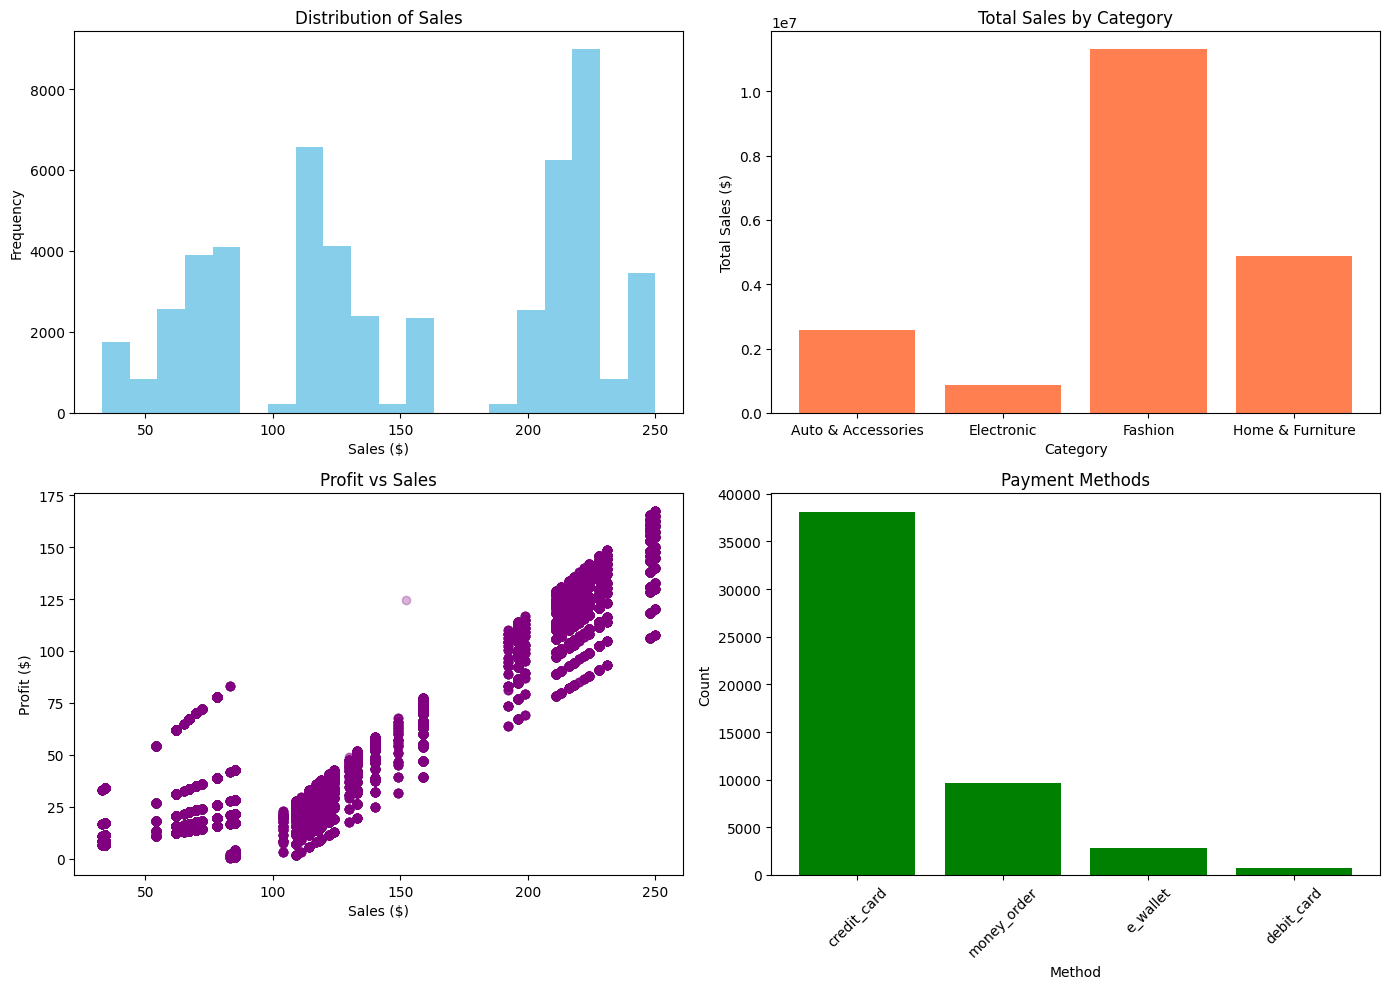

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# Histograma de vendas
ax[0, 0].hist(df["sales"], bins=20, color="skyblue")
ax[0, 0].set_title("Distribution of Sales")
ax[0, 0].set_xlabel("Sales ($)")
ax[0, 0].set_ylabel("Frequency")

# Vendas por categoria
category_sales = df.groupby("product_category")["sales_amount"].sum()
ax[0, 1].bar(category_sales.index, category_sales.values, color="coral")
ax[0, 1].set_title("Total Sales by Category")
ax[0, 1].set_xlabel("Category")
ax[0, 1].set_ylabel("Total Sales ($)")

# Lucro vs Vendas
ax[1, 0].scatter(df["sales"], df["profit"], alpha=0.3, color="purple")
ax[1, 0].set_title("Profit vs Sales")
ax[1, 0].set_xlabel("Sales ($)")
ax[1, 0].set_ylabel("Profit ($)")

# Métodos de pagamento
payment = df["payment_method"].value_counts()
ax[1, 1].bar(payment.index, payment.values, color="green")
ax[1, 1].set_title("Payment Methods")
ax[1, 1].set_xlabel("Method")
ax[1, 1].set_ylabel("Count")
ax[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

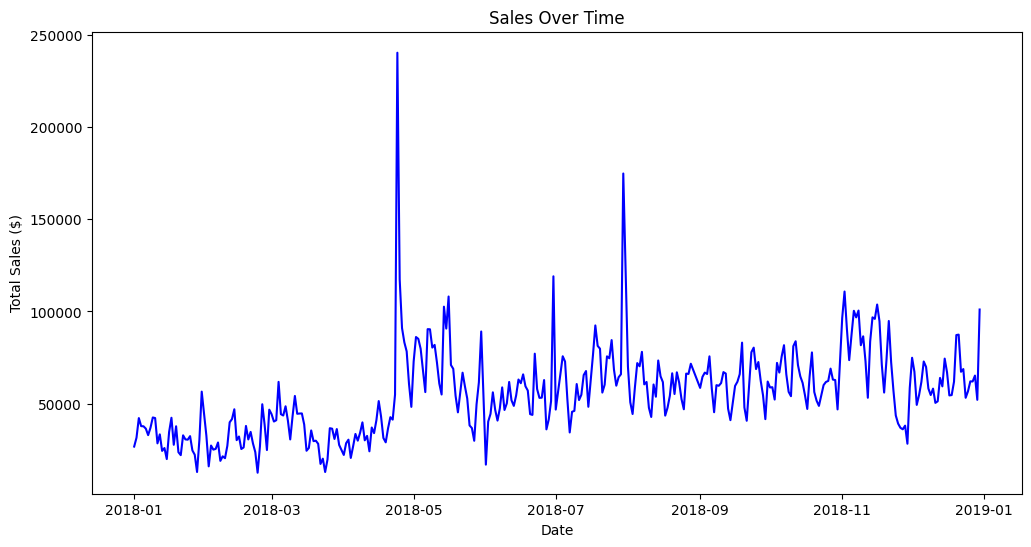

In [ ]:
sales_time = df.groupby("order_date")["sales_amount"].sum()

plt.figure(figsize=(12, 6))
plt.plot(sales_time.index, sales_time.values, color="blue")
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales ($)")
plt.show()

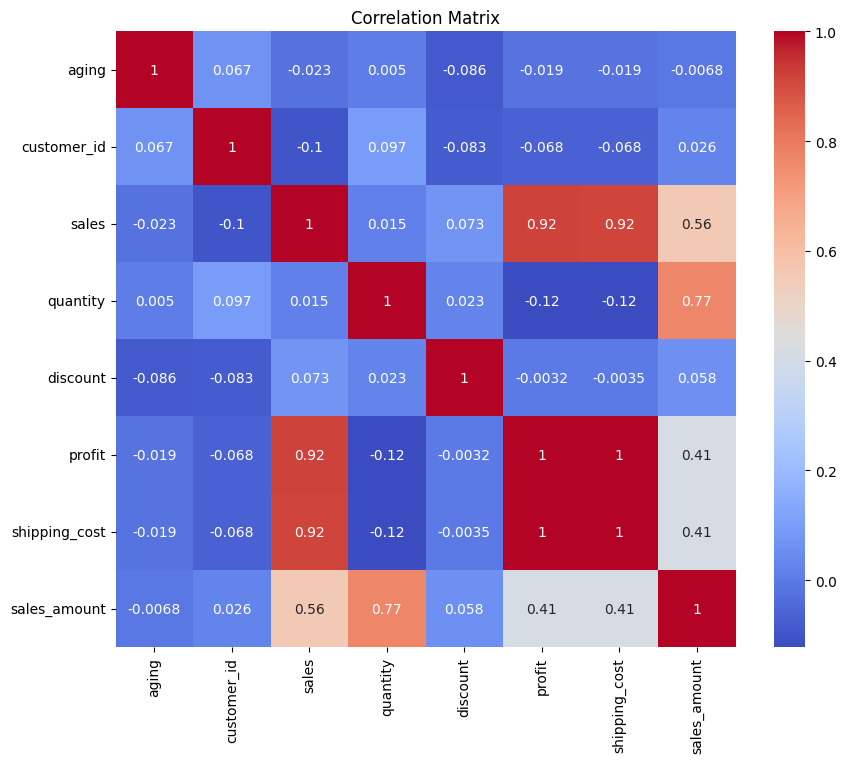

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()